# 03 — Beta(α, β) Reputation and Exponential Decay

Each peer's reputation lives as a Beta(α, β) distribution. α counts "good" evidence (valid signatures, observation matches), β counts "bad" (rejections, geometric inconsistency). Reputation = α / (α + β).

Two design choices made the engine work:

1. **`record_accept` α-tightening (0.1, not 1.0)** — having a valid signature earns a small reward, so behavioral evidence (1.0 per voting match) dominates the score.
2. **10 s exponential decay half-life toward (1, 1)** — old behavior fades; a healed liar rehabilitates over a few half-lives.

## Operator question

**If a drone has one bad tick, is it banned forever?**

Reputation that doesn't forgive is reputation that doesn't work — every
honest drone produces noise, every UWB link occasionally NLOSs, every
IMU drifts. A useful trust system has to be *recoverable*. This
notebook teaches the math that makes recovery automatic: Beta(α, β)
priors, α-tightening on agreement, and exponential decay with a 10s
half-life that pulls evidence back toward the uniform prior.

In the React Workshop Console, Lesson 02 (`recovery_after_lie`) is the
operational demo — A0 lies for 20 ticks, the reputation collapses, then
recovers as decay erodes the bad-evidence accumulator. The dip-then-
recover shape is the visible expression of the math derived here.


In [1]:
%matplotlib inline
from ipywidgets import interact, FloatSlider
from specter.viz.notebook import beta_pdf, decay_trajectory
from specter.telemetry import ReputationTrace

## Intuition: slide α and β; watch the prior become a posterior

The Beta(1, 1) prior is uniform — we have no evidence yet. As α grows, the mass concentrates near 1.0 ("likely honest"); as β grows, near 0.0 ("likely Byzantine"). When α ≈ β, the score sits near 0.5.

interactive(children=(FloatSlider(value=2.0, description='alpha', max=20.0, min=1.0, step=0.5), FloatSlider(va…

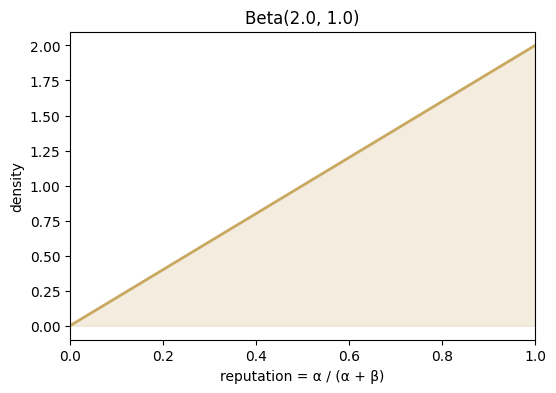

In [2]:
interact(
    beta_pdf,
    alpha=FloatSlider(min=1.0, max=20.0, step=0.5, value=2.0),
    beta_param=FloatSlider(min=1.0, max=20.0, step=0.5, value=1.0),
);

## Intuition: 10 s decay pulls evidence back toward the prior

Feed 5 α-events at 1 Hz into a real `BetaTrustEvaluator`, then let 30 s of silence elapse. The decay you see on the plot is the library's own `_decay()` — not a parallel reimplementation. Half-life is 10 s; after one half-life, the gap (α − 1) is halved.

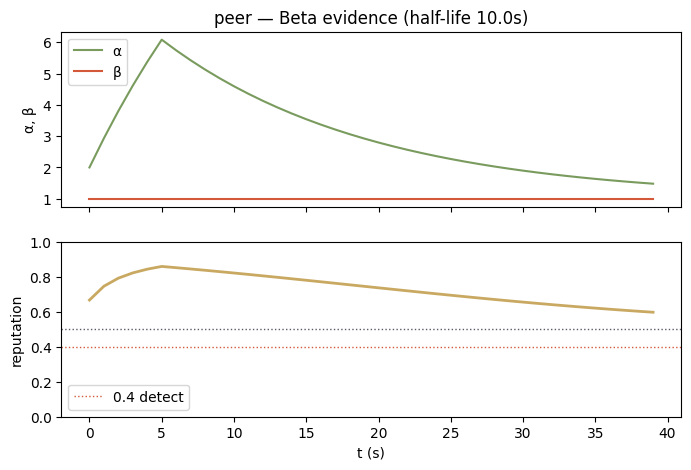

In [3]:
from specter.trust.evaluator import BetaTrustEvaluator

evaluator = BetaTrustEvaluator()
trace = ReputationTrace()
SECOND = 1_000_000_000

# 5 α-events at 1 Hz, then 30 s of silence. The evaluator's own _decay()
# runs the math — the only thing we drive from outside is the wall clock
# (in real life this advances on envelope timestamps).
for i in range(40):
    t_ns = i * SECOND
    evaluator._decay_clock_ns = t_ns
    if i < 6:
        evaluator.observe('peer', {'alpha': 1.0})
    alpha, beta = evaluator.gossip_snapshot()['peer']
    trace.record('peer', alpha, beta, t_ns)

fig = decay_trajectory(trace, 'peer')

## Claim: under realistic radio jitter the engine still detects within budget

The decay window's defense surface degrades as inter-arrival jitter rises. The calibration sweep (`tests/eval/test_calibration.py::test_decay_window_jitter_inflection`, ADR 0013) measured the inflection point.

Single-pose-liar baseline detection: **tick 2** (no jitter).

| Jitter | Detection tick | Note |
|---|---|---|
| 1 ms | 2 | unchanged |
| 5 ms | 2 | unchanged |
| 10 ms | 2 | unchanged |
| 25 ms | 3 | within budget |
| 50 ms | 4 | within budget |
| **100 ms** | **5** | **2.5× baseline — inflection** |

Up to 50 ms is absorbed without crossing the 2× budget. ADR 0013 records the result; tuning is deferred until Phase 1+ hardware produces real-radio jitter.

## Limit

The 10 s decay constant is a tuning choice for the simulated cadence (200 Hz IMU, 10 Hz lidar). **No real-radio measurement informs it yet** — that's the open work in `docs/HARDWARE_READINESS.md`. Don't over-fit notebook visualizations to this constant; the constant will move once Phase 1+ delivers ground truth.

See ADR 0013 for the calibration table that this notebook visualizes.